# 

Egor Lvov, Kovacs Renata, Dzhekshenova Aiana


## Sensitivity Analysis
The following notebook demonstrates methods of sensitivity analysis. It does so by showcasing time constrast between two possible solutions to the change in LP's parameters: 
1) complete re-solve 
2) Shortcuts to calculation provided via $B^{-1}$

In the preliminary problem discussion I am going to use the following pipeline from the course textbook  (p. 275, Operation Research applications and algorithms)

> Suppose we have solved an LP and found that **BV** is an optimal basis. To determine if any change causes BV to be no longer optimal:
>
> **Step 1.** Determine how the change affects the RHS and row 0 of the optimal tableau.
>
> **Step 2.** If every row 0 coefficient is ≥ 0 and every RHS is ≥ 0, BV is still optimal. Otherwise BV is no longer optimal.

>There are two ways BV can stop being optimal
>
>1) row 0 has a negative coefficient
>2) RHS has a negative value

Code would demonstrate the decision making required for diagnosis between 3 cases (remain optimal, non-optimal 1, non-optimal 2). Basis recalculation with simplex or dual simplex will not be covered. Without simplex follow up, the difference between diagnosis between cases is negligeble, so timing utility will always use only one case.

### Problem setup

All of the examples below assume this simple system:
```
max  3x₁ + 5x₂
s.t. 2x₁ +  x₂ ≤ 10
      x₁ + 3x₂ ≤ 12
      x₁, x₂  ≥  0
```
With optimal solution: **x₁ = 3.6, x₂ = 2.8, obj = 24.8**.  
and variables:
- Basic: x₁, x₂.
- Nonbasic: s₁, s₂.

---
## Building Blocks

Here I define important linear algebra objects that would be used in the examples

In [ ]:
import numpy as np
import time
from scipy.optimize import linprog
 
# ── problem data ──────────────────────────────────────────────────────────────
c    = np.array([-3., -5.])
A    = np.array([[2., 1.],
                 [1., 3.]])
b    = np.array([10., 12.])
bnds = [(0, None), (0, None)]
 
# ── solve once ────────────────────────────────────────────────────────────────
res   = linprog(c, A_ub=A, b_ub=b, bounds=bnds, method='highs')
x_opt = res.x
obj   = -res.fun
 
# ── build full augmented system [A | I_m] ─────────────────────────────────────
m, n   = A.shape                              # m constraints, n structural vars
A_full = np.hstack([A, np.eye(m)])            # (m × n+m)
c_full = np.append(c, np.zeros(m))            # length n+m
 
# ── recover basis: find the m basic variable indices ─────────────────────────
slack     = b - A @ x_opt                     # slack values at optimum
x_full    = np.append(x_opt, slack)           # all n+m variable values
 
tol       = 1e-6
basic_idx = np.where(x_full > tol)[0]         # non-zero → basic
 
# guard: if degenerate ties give != m basics, pick top-m by value
if len(basic_idx) != m:
    basic_idx = np.argsort(x_full)[::-1][:m]
 
# ── B: square (m×m) basis matrix ─────────────────────────────────────────────
B     = A_full[:, basic_idx]
B_inv = np.linalg.inv(B)
 
# ── cB, shadow prices, reduced costs ─────────────────────────────────────────
cB = c_full[basic_idx]
y  = cB @ B_inv
rc = c_full - y @ A_full
 
# ── output (unchanged) ───────────────────────────────────────────────────────
print(f"  x*    = {x_opt}")
print(f"  obj   = {obj}")
print()
print(f"  B     =\n{B}")
print(f"  B_inv =\n{B_inv}")
print()
print(f"  cB    = {cB}")
print(f"  y     = cB @ B_inv  = {y}     <- shadow prices")
print(f"  rc    = c - y @ A   = {np.round(rc, 4)}  <- row 0 (basic=0, nonbasic≥0 at optimum)")
print()
print(f"  verify x_B = B_inv @ b = {B_inv @ b}  (matches x*)")

  x*    = [3.6 2.8]
  obj   = 24.800000000000004

  B     =
[[2. 1.]
 [1. 3.]]
  B_inv =
[[ 0.6 -0.2]
 [-0.2  0.4]]

  cB    = [-3. -5.]
  y     = cB @ B_inv  = [-0.8 -1.4]     <- shadow prices
  rc    = c - y @ A   = [-0.  -0.   0.8  1.4]  <- row 0 (basic=0, nonbasic≥0 at optimum)

  verify x_B = B_inv @ b = [3.6 2.8]  (matches x*)


In [2]:
# ── timing utility ────────────────────────────────────────────────────────────
def time_it(fn, reps=2000):
    t0 = time.perf_counter()
    for _ in range(reps): result = fn()
    return (time.perf_counter() - t0) / reps * 1e6, result
 
def resolv(c_, A_, b_, bnds_=None):
    return linprog(c_, A_ub=A_, b_ub=b_, bounds=bnds_ or bnds, method='highs')
 
timings = {}

# Changes
Our textbook provides 6 possible types of alteration of LP's parameters.


### Change 1 — Objective coefficient of a nonbasic variable

**Step 1.** Only row 0 changes. The new reduced cost of variable j is:
$$rc_j^{new} = c_j^{new} - y \cdot a_j$$
RHS is unaffected (x* does not change).

**Step 2.** Check sign of $rc_j^{new}$:
- $rc_j^{new} \geq 0$ → **BV still optimal**, x* and obj unchanged
- $rc_j^{new} < 0$ → **suboptimal basis**, variable j wants to enter → primal pivot

RHS violation is impossible here — x* is untouched.

In [3]:
# Pick the first nonbasic variable as the demo target for C1
nonbasic_idx = np.array([i for i in range(n + m) if i not in basic_idx])
nb1          = nonbasic_idx[0]                 # index of first nonbasic variable
a_s1         = A_full[:, nb1]                  # its column in the augmented system
rc_nb1       = rc[nb1]                         # its current reduced cost (≥ 0)
 
# Three scenarios: unchanged, halfway to zero, just past zero
scenarios_c1 = [
    ('still optimal', c_full[nb1]),                    # original  → rc unchanged
    ('still optimal', c_full[nb1] - rc_nb1 * 0.5),    # halfway   → rc halved
    ('suboptimal',    c_full[nb1] - rc_nb1 - 0.5),    # past zero → rc negative
]
 
print(f"  y = {y},  a_s1 = {a_s1}")
print(f"  formula: rc_new = c_s1_new - y @ a_s1\n")
 
for label, c_s1_new in scenarios_c1:
    rc_new = c_s1_new - y @ a_s1
    outcome = 'BV optimal' if rc_new >= 0 else 'SUBOPTIMAL — s1 wants to enter (primal pivot)'
    print(f"  c_s1 = {c_s1_new:+.1f}  →  rc_new = {rc_new:.4f}  →  {outcome}")
 
# timing on scenario 1 (representative — same cost regardless of outcome)
c_s1_timing = c_full[nb1] - rc_nb1 * 0.5
t_s, _ = time_it(lambda: c_s1_timing - y @ a_s1)
t_r, _ = time_it(lambda: resolv(c, A, b))
timings['C1'] = (t_s, t_r)
print(f"\n  check: {t_s:.2f} µs  |  full re-solve: {t_r:.2f} µs  |  speedup: {t_r/t_s:.0f}×")

  y = [-0.8 -1.4],  a_s1 = [1. 0.]
  formula: rc_new = c_s1_new - y @ a_s1

  c_s1 = +0.0  →  rc_new = 0.8000  →  BV optimal
  c_s1 = -0.4  →  rc_new = 0.4000  →  BV optimal
  c_s1 = -1.3  →  rc_new = -0.5000  →  SUBOPTIMAL — s1 wants to enter (primal pivot)

  check: 1.96 µs  |  full re-solve: 1108.08 µs  |  speedup: 566×



### Change 2 — Objective coefficient of a basic variable

**Step 1.** Changing a basic variable's cost shifts the shadow prices, which updates **all** of row 0:
$$y^{new} = c_B^{new} \cdot B^{-1}$$
$$rc_j^{new} = c_j - y^{new} \cdot a_j \quad \text{for all } j$$
RHS unaffected (x* does not change).

**Step 2.** Check all nonbasic reduced costs:
- all $rc_j^{new} \geq 0$ → **BV still optimal**, same x*, new obj value
- any $rc_j^{new} < 0$ → **suboptimal basis** → primal pivot

RHS violation is impossible here.

In [4]:
cB_orig   = cB.copy()
_bi       = int(np.argmin(cB_orig))           # index of most-negative basic cost
cB_nudge  = cB.copy(); cB_nudge[_bi] = cB_orig[_bi] * 0.8   # 20% cheaper
cB_sub    = cB.copy(); cB_sub[_bi]   = cB_orig[_bi] * 0.2   # 80% cheaper → likely suboptimal
 
scenarios_c2 = [
    ('still optimal', cB_orig),
    ('still optimal', cB_nudge),
    ('suboptimal',    cB_sub),
]
 
print(f"  B_inv =\n{B_inv}\n")
print(f"  formula: y_new = cB_new @ B_inv,  rc_new = c - y_new @ A\n")
 
for label, cB_new in scenarios_c2:
    y_new        = cB_new @ B_inv
    # reconstruct c_full with updated basic costs, zeros for slacks
    c_full_new         = c_full.copy()
    c_full_new[basic_idx] = cB_new
    rc_new       = c_full_new - y_new @ A_full
    rc_nonbasic  = rc_new[nonbasic_idx]           # only nonbasic columns matter
    still_opt    = np.all(rc_nonbasic >= -1e-8)
    obj_new      = -(cB_new @ (B_inv @ b))
    outcome = 'BV optimal' if still_opt else 'SUBOPTIMAL — primal pivot needed'
    print(f"  cB={np.round(cB_new,2)}  →  y_new={np.round(y_new,4)}  →  rc(nonbasic)={np.round(rc_nonbasic,3)}")
    print(f"    new obj={obj_new:.4f}  →  {outcome}\n")
 
t_s, _ = time_it(lambda: (lambda cBn: (cBn @ B_inv, c_full - (cBn @ B_inv) @ A_full))(cB_nudge))
c_timing = c.copy(); c_timing[basic_idx[basic_idx < n]] = cB_nudge[basic_idx < n]
t_r, _ = time_it(lambda: resolv(c_timing, A, b))
timings['C2'] = (t_s, t_r)
print(f"  check: {t_s:.2f} µs  |  full re-solve: {t_r:.2f} µs  |  speedup: {t_r/t_s:.0f}×")

  B_inv =
[[ 0.6 -0.2]
 [-0.2  0.4]]

  formula: y_new = cB_new @ B_inv,  rc_new = c - y_new @ A

  cB=[-3. -5.]  →  y_new=[-0.8 -1.4]  →  rc(nonbasic)=[0.8 1.4]
    new obj=24.8000  →  BV optimal

  cB=[-3. -4.]  →  y_new=[-1. -1.]  →  rc(nonbasic)=[1. 1.]
    new obj=22.0000  →  BV optimal

  cB=[-3. -1.]  →  y_new=[-1.6  0.2]  →  rc(nonbasic)=[ 1.6 -0.2]
    new obj=13.6000  →  SUBOPTIMAL — primal pivot needed

  check: 5.40 µs  |  full re-solve: 987.20 µs  |  speedup: 183×



### Change 3 — Right-hand side of a constraint

**Step 1.** Only the RHS of the tableau changes. Row 0 is unaffected (y and rc unchanged):
$$x_B^{new} = B^{-1}(b + \Delta b)$$
$$obj^{new} = c_B \cdot x_B^{new}$$

**Step 2.** Check sign of $x_B^{new}$:
- all $x_B^{new} \geq 0$ → **BV still optimal**, new x* and obj values given directly
- any $x_B^{new} < 0$ → **infeasible basis** → dual pivot

Row 0 violation is impossible here — reduced costs are untouched.

In [5]:
# Generic delta-b scenarios: bump first RHS, no change, large negative on first
db_bump     = np.zeros(m); db_bump[0]  =  b[0] * 0.1     # +10% on first constraint
db_zero     = np.zeros(m)                                  # unchanged
db_infeas   = np.zeros(m); db_infeas[0] = -b[0] * 1.5    # -150% → infeasible
 
scenarios_c3 = [
    ('still optimal', db_bump),
    ('still optimal', db_zero),
    ('infeasible',    db_infeas),
]
 
print(f"  B_inv =\n{B_inv}\n")
print(f"  formula: xB_new = B_inv @ (b + db),  feasible if all xB_new >= 0\n")
 
for label, db in scenarios_c3:
    xB_new   = B_inv @ (b + db)
    feasible = np.all(xB_new >= 0)
    obj_new  = -(cB @ xB_new)
    outcome  = f'BV optimal  new x*={np.round(xB_new,3)}  new obj={obj_new:.4f}' if feasible else 'INFEASIBLE BASIS — dual pivot needed'
    print(f"  db={np.round(db,2)}  →  xB_new={np.round(xB_new,4)}  →  {outcome}")
 
t_s, _ = time_it(lambda: B_inv @ (b + db_bump))
t_r, _ = time_it(lambda: resolv(c, A, b + db_bump))
timings['C3'] = (t_s, t_r)
print(f"\n  check: {t_s:.2f} µs  |  full re-solve: {t_r:.2f} µs  |  speedup: {t_r/t_s:.0f}×")

  B_inv =
[[ 0.6 -0.2]
 [-0.2  0.4]]

  formula: xB_new = B_inv @ (b + db),  feasible if all xB_new >= 0

  db=[1. 0.]  →  xB_new=[4.2 2.6]  →  BV optimal  new x*=[4.2 2.6]  new obj=25.6000
  db=[0. 0.]  →  xB_new=[3.6 2.8]  →  BV optimal  new x*=[3.6 2.8]  new obj=24.8000
  db=[-15.   0.]  →  xB_new=[-5.4  5.8]  →  INFEASIBLE BASIS — dual pivot needed

  check: 2.32 µs  |  full re-solve: 1095.26 µs  |  speedup: 472×



### Change 4 — Column of a nonbasic variable

**Step 1.** Only the reduced cost of that variable changes in row 0. RHS unaffected:
$$rc_j^{new} = c_j - y \cdot a_j^{new}$$

**Step 2.** Same as Change 1 — check sign of $rc_j^{new}$:
- $rc_j^{new} \geq 0$ → **BV still optimal**
- $rc_j^{new} < 0$ → **suboptimal basis** → primal pivot

Note: same formula as C1, but $a_j$ changes instead of $c_j$.

In [6]:
c_s1 = c_full[nb1]                    # cost of the demo nonbasic variable (unchanged)
a_nb1_orig = A_full[:, nb1]           # original column
 
# Scenarios: original column, scaled up slightly, sign-flipped (→ suboptimal)
scenarios_c4 = [
    ('still optimal', a_nb1_orig),
    ('still optimal', a_nb1_orig * 1.5),
    ('suboptimal',    -a_nb1_orig),
]
 
print(f"  y = {y}")
print(f"  formula: rc_new = c_s1 - y @ a_s1_new\n")
 
for label, a_s1_new in scenarios_c4:
    rc_new  = c_s1 - y @ a_s1_new
    outcome = 'BV optimal' if rc_new >= 0 else 'SUBOPTIMAL — s1 wants to enter (primal pivot)'
    print(f"  a_s1={np.round(a_s1_new,2)}  →  rc_new = {rc_new:.4f}  →  {outcome}")
 
a_timing = a_nb1_orig * 1.5
t_s, _ = time_it(lambda: c_s1 - y @ a_timing)
A_eq4 = A_full.copy(); A_eq4[:, nb1] = a_timing
t_r, _ = time_it(lambda: linprog(c_full, A_eq=A_eq4, b_eq=b, bounds=[(0,None)]*(n+m), method='highs'))
timings['C4'] = (t_s, t_r)
print(f"\n  check: {t_s:.2f} µs  |  full re-solve: {t_r:.2f} µs  |  speedup: {t_r/t_s:.0f}×")

  y = [-0.8 -1.4]
  formula: rc_new = c_s1 - y @ a_s1_new

  a_s1=[1. 0.]  →  rc_new = 0.8000  →  BV optimal
  a_s1=[1.5 0. ]  →  rc_new = 1.2000  →  BV optimal
  a_s1=[-1. -0.]  →  rc_new = -0.8000  →  SUBOPTIMAL — s1 wants to enter (primal pivot)

  check: 1.96 µs  |  full re-solve: 1442.45 µs  |  speedup: 735×



### Change 5 — Adding a new variable

**Step 1.** A new column appears in row 0. RHS unaffected:
$$rc_{new} = c_{new} - y \cdot a_{new}$$

**Step 2.** Same check — sign of $rc_{new}$:
- $rc_{new} \geq 0$ → **BV still optimal**, new variable stays out
- $rc_{new} < 0$ → **suboptimal basis**, new variable wants to enter → primal pivot

Identical formula to C1 and C4. This is the foundation of column generation.

In [7]:
a_new = np.ones(m)                    # new variable: 1 unit of each resource
 
# rc_threshold is the cost that makes rc exactly 0: c_new = y @ a_new
rc_threshold = y @ a_new
scenarios_c5 = [
    ('stays out',  rc_threshold + 0.2),    # rc = +0.2  → stays out
    ('enters',     rc_threshold - 0.3),    # rc = -0.3  → wants to enter
    ('enters',     rc_threshold - 0.8),    # rc = -0.8  → strongly wants to enter
]
 
print(f"  y = {y},  a_new = {a_new}")
print(f"  formula: rc_new = c_new - y @ a_new\n")
 
for label, c_new in scenarios_c5:
    rc_new  = c_new - y @ a_new
    outcome = 'BV optimal — new var stays out' if rc_new >= 0 else 'SUBOPTIMAL — new var wants to enter (primal pivot)'
    print(f"  c_new = {c_new:+.1f}  →  rc_new = {rc_new:.4f}  →  {outcome}")
 
c_new_timing = rc_threshold + 0.2
t_s, _ = time_it(lambda: c_new_timing - y @ a_new)
A_ext = np.column_stack([A, a_new]); c_ext = np.append(c, c_new_timing)
t_r, _ = time_it(lambda: resolv(c_ext, A_ext, b, bnds+[(0,None)]))
timings['C5'] = (t_s, t_r)
print(f"\n  check: {t_s:.2f} µs  |  full re-solve: {t_r:.2f} µs  |  speedup: {t_r/t_s:.0f}×")

  y = [-0.8 -1.4],  a_new = [1. 1.]
  formula: rc_new = c_new - y @ a_new

  c_new = -2.0  →  rc_new = 0.2000  →  BV optimal — new var stays out
  c_new = -2.5  →  rc_new = -0.3000  →  SUBOPTIMAL — new var wants to enter (primal pivot)
  c_new = -3.0  →  rc_new = -0.8000  →  SUBOPTIMAL — new var wants to enter (primal pivot)

  check: 2.26 µs  |  full re-solve: 1135.84 µs  |  speedup: 502×



### Change 6 — Adding a new constraint

**Step 1.** A new row appears. Row 0 is unaffected. The new constraint introduces a slack variable — check whether current x* satisfies it:
$$violation = a_{con} \cdot x^* - b_{con}$$

**Step 2.**
- $violation \leq 0$ → **BV still optimal**, new constraint is redundant
- $violation > 0$ → **infeasible basis**, x* violates new constraint → dual pivot

Row 0 violation is impossible — reduced costs are untouched by adding a constraint.

In [8]:
a_con = np.ones(n)                    # new constraint: sum of all structural vars ≤ b_con
current_val = a_con @ x_opt           # current value of a_con @ x*
 
scenarios_c6 = [
    ('redundant',  current_val * 1.25),   # 25% slack  → no violation
    ('tight',      current_val),          # exactly binding, still feasible
    ('infeasible', current_val * 0.75),   # 25% below  → violation
]
 
print(f"  x* = {x_opt},  a_con @ x* = {current_val:.4f}")
print(f"  formula: violation = a_con @ x* - b_con\n")
 
for label, b_con in scenarios_c6:
    viol    = a_con @ x_opt - b_con
    outcome = 'BV optimal — constraint redundant' if viol <= 0 else 'INFEASIBLE BASIS — dual pivot needed'
    print(f"  b_con = {b_con:.4f}  →  violation = {viol:.4f}  →  {outcome}")
 
b_con_timing = current_val * 0.75
t_s, _ = time_it(lambda: a_con @ x_opt - b_con_timing)
t_r, _ = time_it(lambda: resolv(c, np.vstack([A, a_con]), np.append(b, b_con_timing)))
timings['C6'] = (t_s, t_r)
print(f"\n  check: {t_s:.2f} µs  |  full re-solve: {t_r:.2f} µs  |  speedup: {t_r/t_s:.0f}×")

  x* = [3.6 2.8],  a_con @ x* = 6.4000
  formula: violation = a_con @ x* - b_con

  b_con = 8.0000  →  violation = -1.6000  →  BV optimal — constraint redundant
  b_con = 6.4000  →  violation = 0.0000  →  BV optimal — constraint redundant
  b_con = 4.8000  →  violation = 1.6000  →  INFEASIBLE BASIS — dual pivot needed

  check: 1.84 µs  |  full re-solve: 1466.84 µs  |  speedup: 796×


---
### Plots for the time comparison

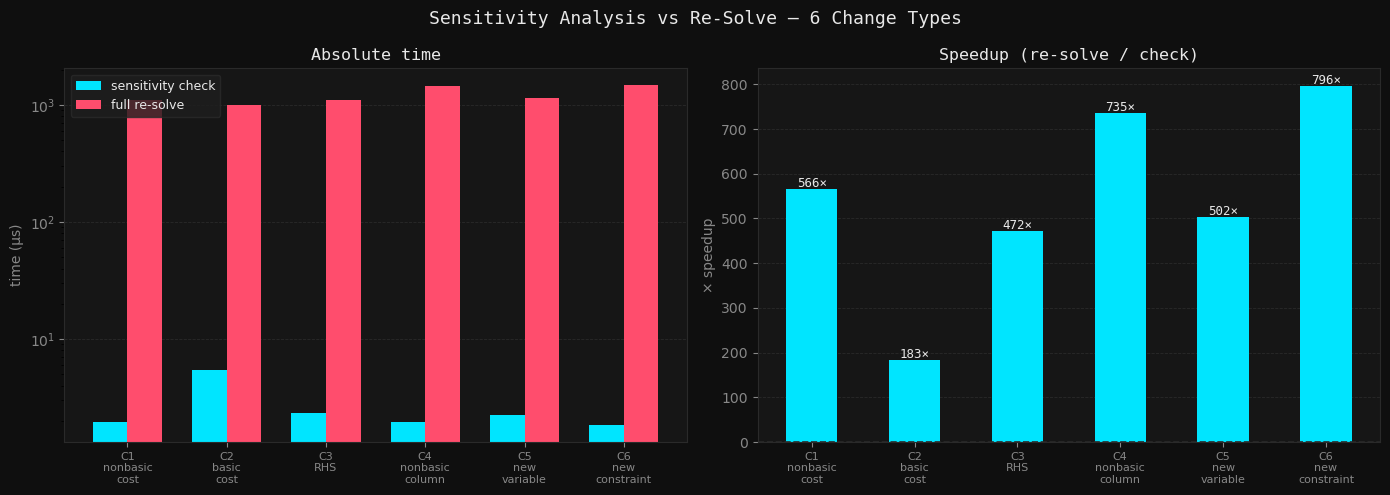


       check (µs)  re-solve (µs)    speedup
--------------------------------------------
C1           1.96        1108.08       566×
C2           5.40         987.20       183×
C3           2.32        1095.26       472×
C4           1.96        1442.45       735×
C5           2.26        1135.84       502×
C6           1.84        1466.84       796×

--- what's being reused ---
  C1: y (shadow prices)
  C2: B_inv → new y → new rc
  C3: B_inv
  C4: y (shadow prices)
  C5: y (shadow prices)
  C6: x*


In [9]:
import matplotlib.pyplot as plt
import numpy as np
 
DARK='#0f0f0f'; PANEL='#161616'; GRID='#2a2a2a'
ACC1='#00e5ff'; ACC2='#ff4d6d'; TEXT='#e8e8e8'; SUB='#888888'
 
keys     = list(timings.keys())
sens_t   = [timings[k][0] for k in keys]
res_t    = [timings[k][1] for k in keys]
speedups = [r/s for r,s in zip(res_t, sens_t)]
xlabels  = ['C1\nnonbasic\ncost', 'C2\nbasic\ncost',
            'C3\nRHS', 'C4\nnonbasic\ncolumn',
            'C5\nnew\nvariable', 'C6\nnew\nconstraint']
x = np.arange(len(keys))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Sensitivity Analysis vs Re-Solve — 6 Change Types',
             color=TEXT, fontsize=13, fontfamily='monospace')
 
ax = axes[0]; ax.set_facecolor(PANEL)
w = 0.35
ax.bar(x-w/2, sens_t, w, color=ACC1, label='sensitivity check')
ax.bar(x+w/2, res_t,  w, color=ACC2, label='full re-solve')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8, color=TEXT)
ax.set_ylabel('time (µs)', color=SUB); ax.set_yscale('log')
ax.set_title('Absolute time', color=TEXT, fontfamily='monospace')
ax.tick_params(colors=SUB); ax.yaxis.grid(True, color=GRID, lw=0.6, ls='--')
ax.set_axisbelow(True)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.legend(fontsize=9, facecolor='#1e1e1e', edgecolor=GRID, labelcolor=TEXT)
 
ax2 = axes[1]; ax2.set_facecolor(PANEL)
bars = ax2.bar(x, speedups, color=ACC1, width=0.5)
for bar, val in zip(bars, speedups):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{val:.0f}×', ha='center', color=TEXT, fontsize=9, fontfamily='monospace')
ax2.axhline(1, color=GRID, lw=1.2, ls='--')
ax2.set_xticks(x); ax2.set_xticklabels(xlabels, fontsize=8, color=TEXT)
ax2.set_ylabel('× speedup', color=SUB)
ax2.set_title('Speedup (re-solve / check)', color=TEXT, fontfamily='monospace')
ax2.tick_params(colors=SUB); ax2.yaxis.grid(True, color=GRID, lw=0.6, ls='--')
ax2.set_axisbelow(True)
for sp in ax2.spines.values(): sp.set_edgecolor(GRID)
 
plt.tight_layout(); plt.show()
 
print(f"\n{'':4} {'check (µs)':>12} {'re-solve (µs)':>14} {'speedup':>10}")
print('-' * 44)
for k,s,r in zip(keys,sens_t,res_t):
    print(f"{k:<4} {s:>12.2f} {r:>14.2f} {r/s:>9.0f}×")
 
print("\n--- what's being reused ---")
reuse = {'C1':'y (shadow prices)', 'C2':'B_inv → new y → new rc',
         'C3':'B_inv', 'C4':'y (shadow prices)',
         'C5':'y (shadow prices)', 'C6':'x*'}
for k,v in reuse.items():
    print(f"  {k}: {v}")